# Data Ingestion & Loading
In this initial step, we load the raw dataset into the environment. We import necessary libraries (Pandas, NumPy, Matplotlib, Seaborn) and read the CSV file to begin the data science lifecycle.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import dash_bootstrap_components as dbc
import os
import threading
from flask import Flask, request, jsonify, render_template
from flask_cors import CORS
import statsmodels

In [2]:
CreditScore = pd.read_csv(r'CreditScore.csv', low_memory=False)

# Preliminary Data Inspection (Light EDA)
Before modifying the data, we perform a "health check" to understand its structure and quality. We inspect the first few rows, check data types, and identify obvious errors—such as numerical columns appearing as objects (strings) due to formatting issues like underscores or special characters.

In [3]:
CreditScore.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529544,High_spent_Small_value_payments,312.4940887,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.2802216,Low_spent_Large_value_payments,284.6291625,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.69952126,Low_spent_Medium_value_payments,331.2098629,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580744,Low_spent_Small_value_payments,223.4513097,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.42015309,High_spent_Medium_value_payments,341.489231,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.43017233,!@9#%8,340.4792118,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674,Low_spent_Small_value_payments,244.5653167,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.78521651,High_spent_Medium_value_payments,358.1241676,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.2918252,Low_spent_Small_value_payments,470.6906269,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123783,High_spent_Large_value_payments,484.5912143,Good


In [4]:
CreditScore.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,99989.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.473372,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.447752,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633330,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [5]:
CreditScore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       99968 non-null   object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             99989 non-null   float64
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [6]:
CreditScore.shape

(100000, 28)

# Data Cleaning, Type Correction, and Outlier Capping
Based on the findings from the preliminary inspection, we address data quality issues to create a usable dataset:
* **Formatting & Type Conversion:** Removing non-numeric characters (e.g., underscores) from `Age` and `Annual_Income` and converting them to numeric.
* **Outlier Capping:** Handling unrealistic values based on domain knowledge (e.g., capping `Num_Credit_Card` at 20, correcting `Age` > 100) to prevent skewing the analysis.
* **Noise Reduction:** Dropping irrelevant identifiers (SSN, ID).
* **Imputation:** Handling missing values.

In [7]:
#drop irrelevant identifiers
cols_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN']
CreditScore = CreditScore.drop(columns=cols_to_drop, errors='ignore')

# LIST OF COLUMNS TO FIX
# These columns contain '_' mixed with numbers
dirty_numeric_cols = [
    'Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
    'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 
    'Monthly_Balance'
]

for col in dirty_numeric_cols:
    
    CreditScore[col] = CreditScore[col].astype(str).str.replace('_', '', regex=False) #Remove '_'
    CreditScore[col] = pd.to_numeric(CreditScore[col], errors='coerce') #Convert to numeric (now "23" becomes 23, not NaN)

print("Garbage characters removed.")

Garbage characters removed.


In [8]:
#List of columns that MUST be integers (No .0 decimals)
int_cols = [
    'Age',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries',
]

# Convert them to nullable Integers ('Int64' handles NaNs and removes decimals)
for col in int_cols:

    CreditScore[col] = CreditScore[col].astype('Int64')

print('Converted Some Numerical Columns To Inegers')

Converted Some Numerical Columns To Inegers


In [9]:
def parse_credit_history(val):
    
    if pd.isna(val): return np.nan
    val = str(val)
    # Check if the expected format "Years" and "Months" exists
    if "Years" in val and "Months" in val:
        try:
            parts = val.split(" Years and ")
            years = int(parts[0])
            months_part = parts[1].split(" Months")[0]
            months = int(months_part)
            return (years * 12) + months
        except:
            return np.nan
    return np.nan

CreditScore['Credit_History_Age_Months'] = CreditScore['Credit_History_Age'].apply(parse_credit_history)
# Drop the original text column
CreditScore = CreditScore.drop(columns=['Credit_History_Age'])

print("Credit History converted to Total Months.")

Credit History converted to Total Months.


In [10]:
# 1. Age: Replace negative values or >100 with the Median
median_age = CreditScore.loc[(CreditScore['Age'] > 0) & (CreditScore['Age'] < 100), 'Age'].median() #imputed with median because it doesnt get affected by outliers
CreditScore.loc[(CreditScore['Age'] < 0) | (CreditScore['Age'] > 100), 'Age'] = median_age

# 2. Num_of_Loan: Replace negative values with 0
CreditScore.loc[CreditScore['Num_of_Loan'] < 0, 'Num_of_Loan'] = 0

print("Outliers treated.")

Outliers treated.


In [11]:
#FIXING UNREASONABLE DATA

# 3. DELAYED PAYMENTS: Fix negatives and cap extreme outliers
CreditScore.loc[CreditScore['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = 0
# Cap at 30 (reasonable high number)
CreditScore.loc[CreditScore['Num_of_Delayed_Payment'] > 30, 'Num_of_Delayed_Payment'] = 30

# 4. INTEREST RATE: Cap at 35%
CreditScore.loc[CreditScore['Interest_Rate'] > 35, 'Interest_Rate'] = 35 #searched on google

# 5. CREDIT INQUIRIES: Cap at 20
CreditScore.loc[CreditScore['Num_Credit_Inquiries'] > 20, 'Num_Credit_Inquiries'] = 20 

# 6. OCCUPATION: Fix missing placeholder
CreditScore['Occupation'] = CreditScore['Occupation'].str.replace('_______', 'Other', regex=False)

# 7. PAYMENT BEHAVIOUR: Fix garbage string
mode_behavior = CreditScore['Payment_Behaviour'].mode()[0] #used mode because its categorical
CreditScore['Payment_Behaviour'] = CreditScore['Payment_Behaviour'].replace('!@9#%8', mode_behavior)

# 8. CREDIT MIX: Fix underscores
CreditScore['Credit_Mix'] = CreditScore['Credit_Mix'].replace('_', 'Standard')

# 9. ALL negatives are garbage errors, we set them to NaN
CreditScore.loc[CreditScore['Monthly_Balance'] < 0, 'Monthly_Balance'] = np.nan

print("All unreasonable rows have been fixed.")

All unreasonable rows have been fixed.


In [12]:
# Cap the outliers in Num_Credit_Card at a reasonable limit (e.g., 20)
# This assumes anyone with > 20 cards is an error, but we treat them as "High Number of Cards"
upper_limit = 20 
CreditScore['Num_Credit_Card'] = CreditScore['Num_Credit_Card'].apply(lambda x: upper_limit if x > upper_limit else x)

print("Outliers capped. Max value is now:", CreditScore['Num_Credit_Card'].max())

Outliers capped. Max value is now: 20


# Exploratory Data Analysis
Now that the data is clean and extreme errors are capped, we analyze the statistical properties of the features. We use visualizations (histograms, boxplots, and correlation matrices) to:
* Understand the distribution of financial behaviors.
* Detect remaining statistical outliers.
* Analyze the balance of the target variable (`Credit_Score`).

<Figure size 1000x500 with 0 Axes>

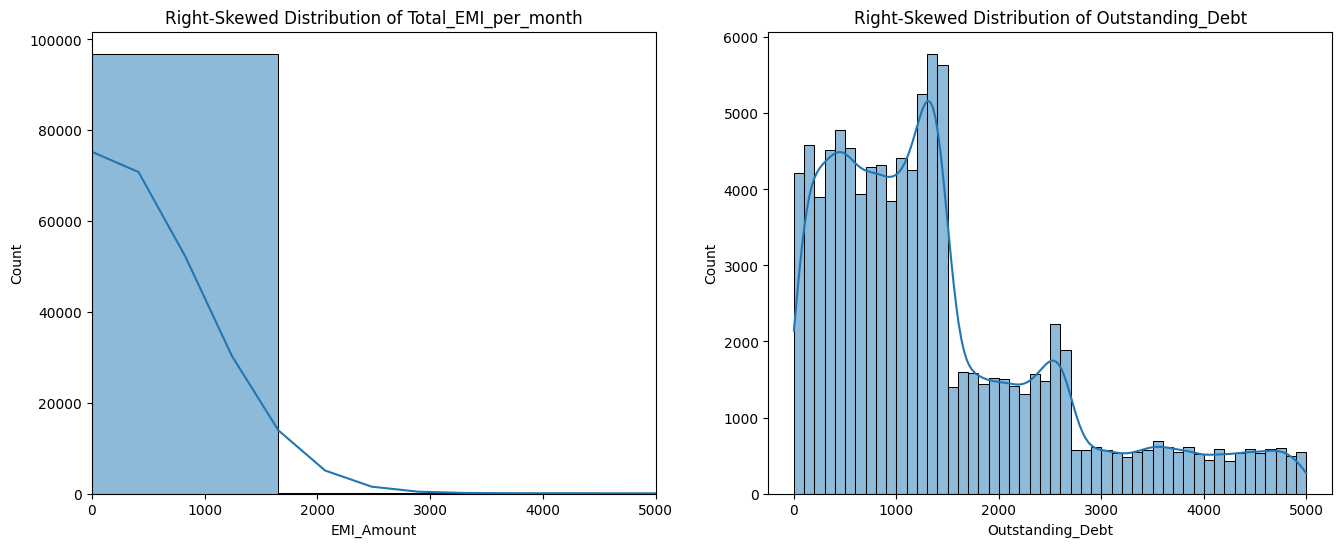

In [13]:
#lets pick Total_EMI_per_month as the example

col1 = 'Total_EMI_per_month'
col2 = 'Outstanding_Debt'

plt.figure(figsize=(10, 5))

#plot the distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(CreditScore[col1].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title(f'Right-Skewed Distribution of {col1}')
axes[0].set_xlim(0, 5000) #zoom in to see the main part
axes[0].set_xlabel('EMI_Amount')
sns.histplot(CreditScore[col2].dropna(), bins=50, kde=True, ax=axes[1])
axes[1].set_title(f'Right-Skewed Distribution of {col2}')
plt.show()

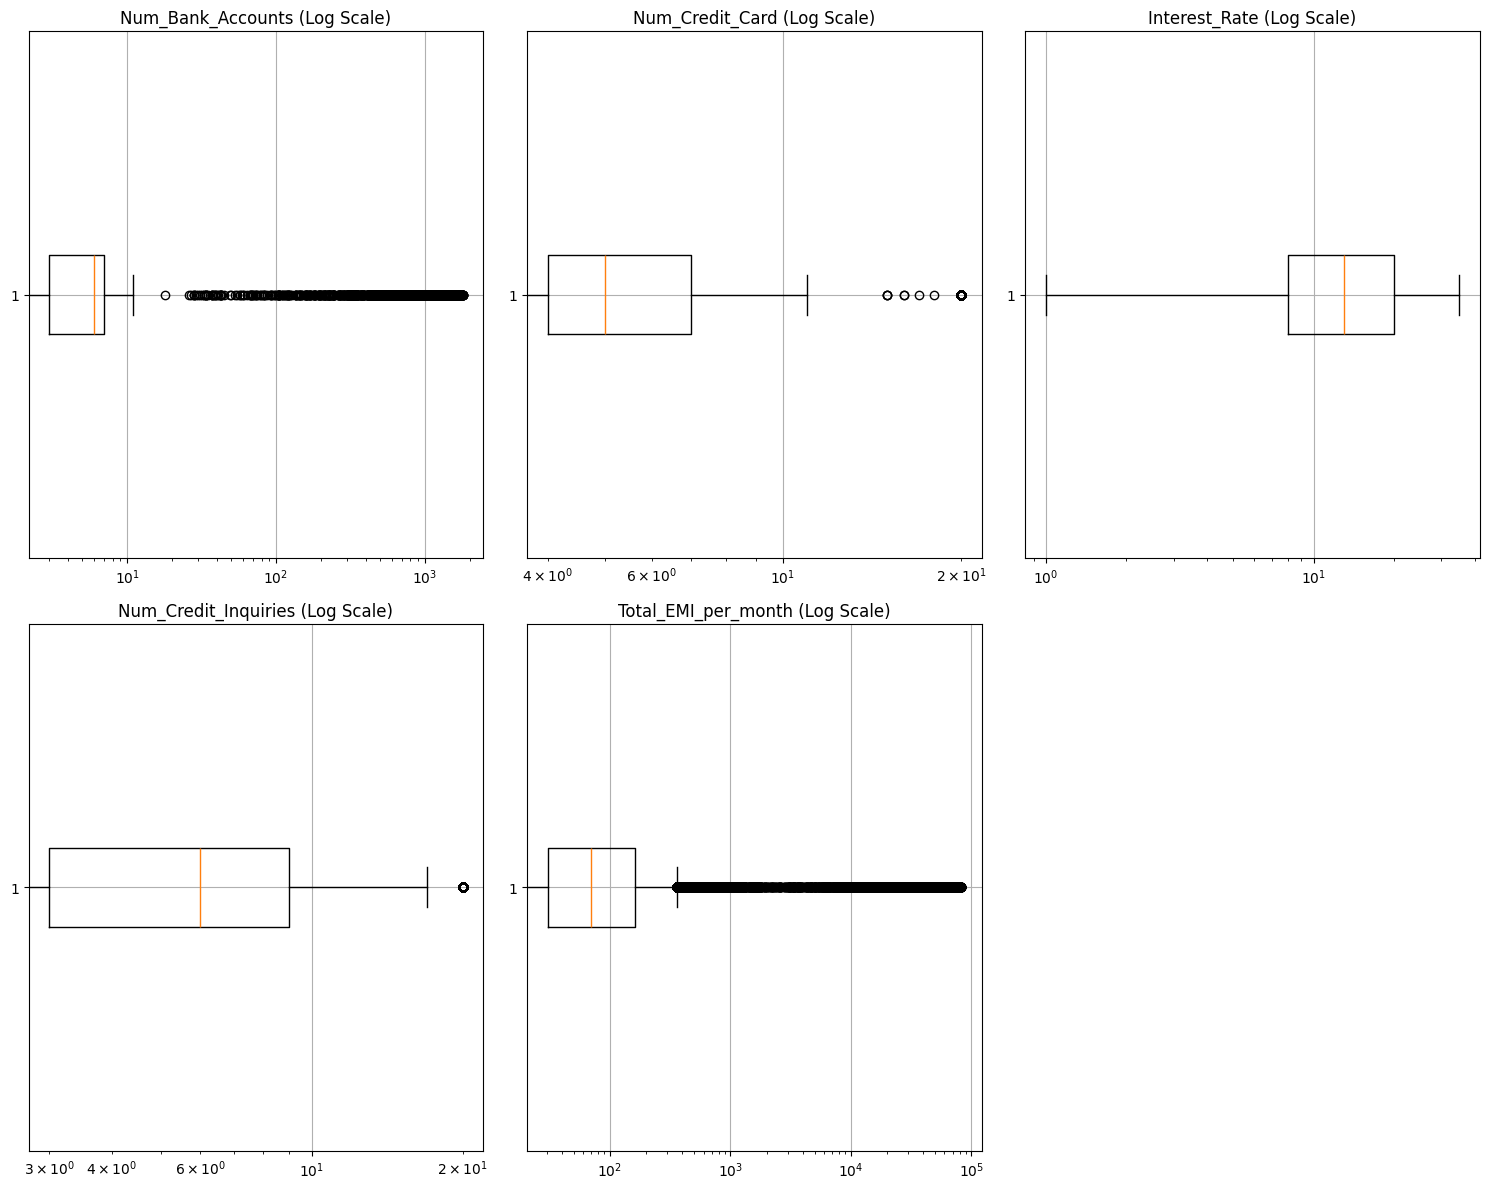

In [14]:
# define the columns you want to plot
columns = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_Credit_Inquiries', 'Total_EMI_per_month']

plt.figure(figsize=(15, 12))

for i, col in enumerate(columns, 1):
    
    plt.subplot(2, 3, i)
    plt.boxplot(CreditScore[col].dropna(), vert=False)
    plt.xscale('log')  #log scale to compresses the huge values so we can see both the box and the outliers.
    plt.title(f'{col} (Log Scale)')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
print("Top 3 Categorical Columns by Variety (Number of Unique Values)") #for categorical features

cat_cols = CreditScore.select_dtypes(include=['object', 'category']) #get only object/categorical columns

print(cat_cols.nunique().sort_values(ascending=False).head(3)) #count unique values and show top 3
print("\n" + "="*50 + "\n") #print new line
print("Top 3 Numeric Columns by Variance") #for numeric features

num_cols = CreditScore.select_dtypes(include=['number']) #get numeric columns

print(num_cols.var().sort_values(ascending=False).head(3)) #calculate variance and show top 3

Top 3 Categorical Columns by Variety (Number of Unique Values)
Type_of_Loan    6260
Occupation        16
Month              8
dtype: int64


Top 3 Numeric Columns by Variance
Annual_Income            2043807772929.203857
Total_EMI_per_month           68990321.584288
Monthly_Inhand_Salary         10135857.609003
dtype: Float64


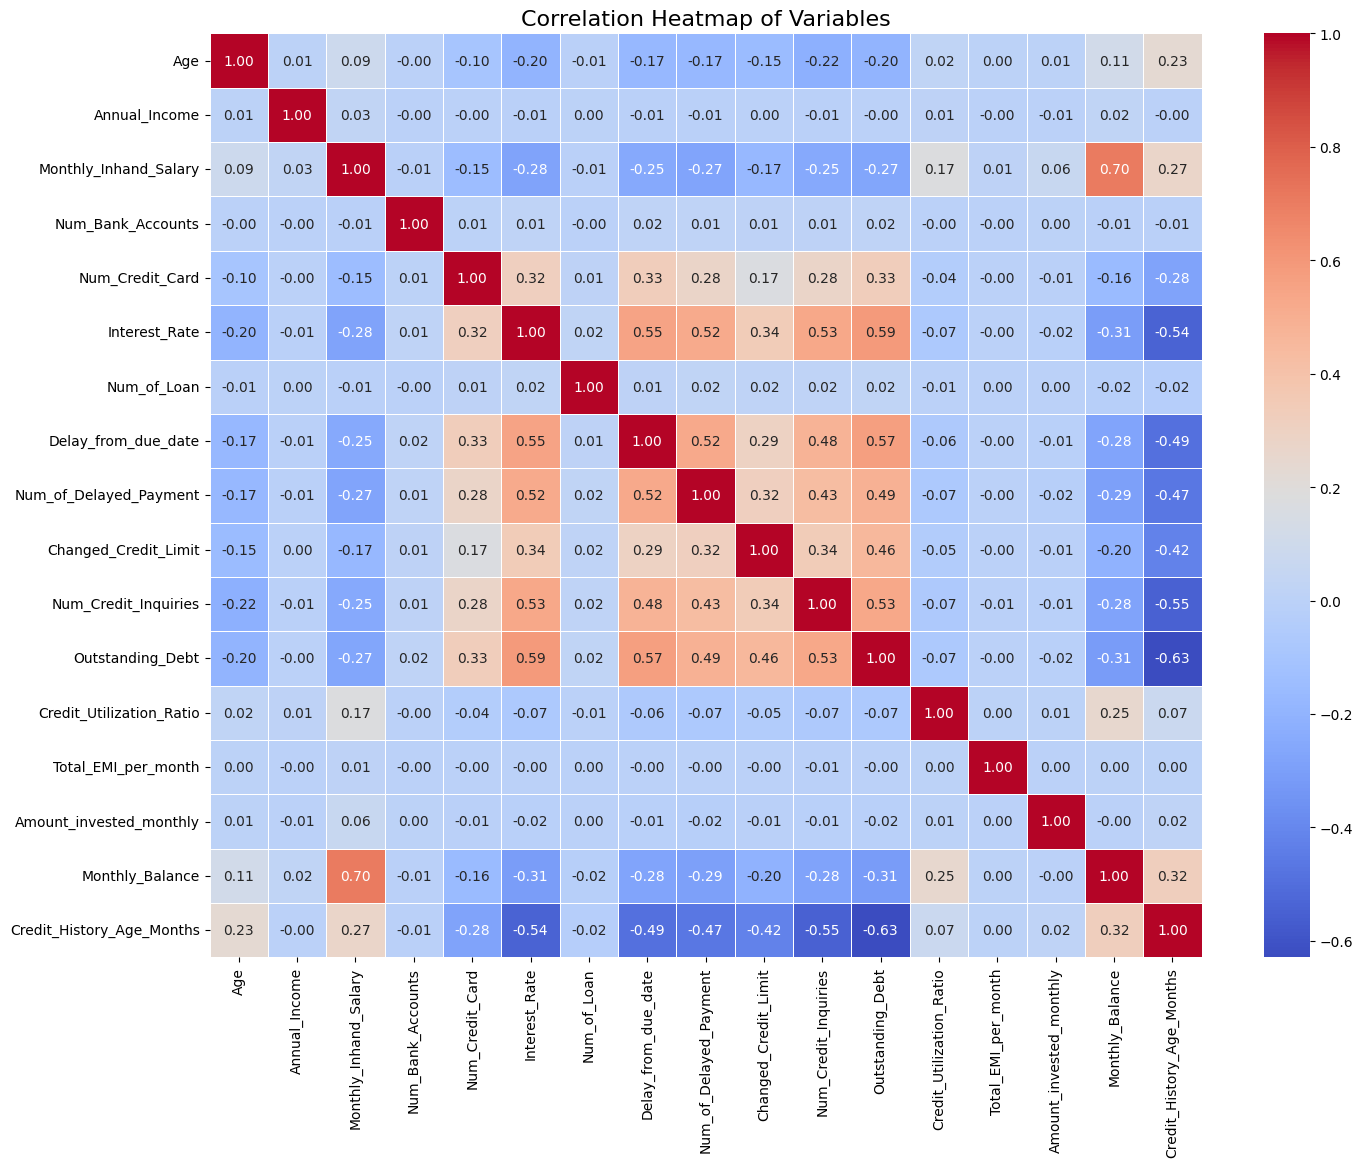

In [16]:
plt.figure(figsize=(16, 12)) #set the figure size (making it large enough to read the numbers)

corr_matrix = CreditScore.corr(numeric_only=True) #calculate the correlation matrix for numeric columns

#annot=True: Writes the number in each box
#fmt=".2f": Formats the numbers to 2 decimal places
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Variables', fontsize=16)
plt.show()

In [18]:
CreditScore['Credit_Score'].value_counts() #values are balanced well enough for machine learning no need for resampling

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

# Feature Engineering and Preprocessing
We prepare the data for the Machine Learning algorithm by translating it into a mathematical format:
* **Categorical Encoding:**
    * **Binary Mapping:** Converting `Payment_of_Min_Amount` into binary values (Yes=1, No=0).
    * **Label Encoding:** Transforming `Payment_Behaviour` and `Credit_Mix` into numeric representations.
* **Scaling:** Applying `RobustScaler` to standardize numerical features. Since we already capped extreme errors in Step 3, this scaler helps handle any remaining natural outliers.
* **Splitting:** Dividing the data into training (80%) and testing (20%) sets.

In [19]:
print("Unique before fix:", CreditScore['Payment_of_Min_Amount'].unique())

Unique before fix: ['No' 'NM' 'Yes']


In [20]:
CreditScore['Payment_of_Min_Amount'] = CreditScore['Payment_of_Min_Amount'].replace('NM', 'No')
CreditScore['Payment_of_Min_Amount'] = CreditScore['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})

print("Unique after fix:", CreditScore['Payment_of_Min_Amount'].unique())

Unique after fix: [0 1]


In [21]:
#Numeric Columns -> Fill with Median
numeric_cols = CreditScore.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    
    CreditScore[col] = CreditScore[col].fillna(CreditScore[col].median()) #better for outliers

#Categorical Columns -> Fill with Mode (Most Frequent)
#Also fix 'Credit_Mix' if it has garbage values like '_'
CreditScore['Credit_Mix'] = CreditScore['Credit_Mix'].replace('_', np.nan) 

categorical_cols = CreditScore.select_dtypes(include=['object']).columns
for col in categorical_cols:
    
    if not CreditScore[col].mode().empty:
        
        CreditScore[col] = CreditScore[col].fillna(CreditScore[col].mode()[0])

print("Missing values imputed.")

Missing values imputed.


In [22]:
CreditScore.to_csv("CreditScoreForSQL.csv", index=False)

print("Data saved successfully for SQL import.")

Data saved successfully for SQL import.


In [23]:
CreditScore.drop(['Month'], axis =1, inplace = True) #not needed in next parts

In [24]:
#Encoding

CreditScore_encoded = CreditScore.copy() #Create Copy

#Manual Mapping (Ordinal)
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
CreditScore_encoded['Credit_Mix'] = CreditScore_encoded['Credit_Mix'].map(credit_mix_map).fillna(1)

target_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
CreditScore_encoded['Credit_Score'] = CreditScore_encoded['Credit_Score'].map(target_map)

#Label Encoding (for Payment_Behaviour)
le = LabelEncoder()
CreditScore_encoded['Payment_Behaviour'] = le.fit_transform(CreditScore_encoded['Payment_Behaviour'].astype(str))

#Dummy Encoding
cols_to_dummy = ['Occupation']

#Create the encoded columns separately
encoded_categories = pd.get_dummies(CreditScore_encoded[cols_to_dummy], prefix='Occupation', drop_first=True)

#Drop the original Nominal columns from df_encoded
CreditScore_encoded.drop(columns=cols_to_dummy, axis=1, inplace=True)

#Concatenate them together
CreditScore_encoded = pd.concat([CreditScore_encoded, encoded_categories], axis=1)

#Remove messy column
if 'Type_of_Loan' in CreditScore_encoded.columns:
    
    CreditScore_encoded = CreditScore_encoded.drop(columns=['Type_of_Loan'])

print("Encoding Complete. Shape:", CreditScore_encoded.shape)

Encoding Complete. Shape: (100000, 36)


In [25]:
#Scaling

CreditScore_scaled = CreditScore_encoded.copy()
scaler = RobustScaler() #better with outliers as it uses IQR

#Select continuous columns (exclude Target and Binary columns like Payment_of_Min_Amount)
continuous_cols = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 
    'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months'
]
cols_to_scale = [c for c in continuous_cols if c in CreditScore_scaled.columns] # Only scale columns that exist

CreditScore_scaled[cols_to_scale] = scaler.fit_transform(CreditScore_scaled[cols_to_scale])

print("Scaling Complete.")
print(CreditScore_scaled[['Payment_of_Min_Amount', 'Age', 'Credit_Score']].head())

Scaling Complete.
   Payment_of_Min_Amount    Age  Credit_Score
0                      0 -0.625             2
1                      0 -0.625             2
2                      0  0.000             2
3                      0 -0.625             2
4                      0 -0.625             2


In [26]:
final_CreditScore = CreditScore_scaled.copy()

final_CreditScore.to_csv("preprocessed_dataset.csv", index=False)

In [29]:
# features X and Target y
# drop the Target column from X, only the Target in y
X = final_CreditScore.drop(columns=['Credit_Score']) 
y = final_CreditScore['Credit_Score']

# split the Data
# 80% training model, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Machine Learning Model Development
We train a Random Forest Classifier to predict credit scores. The process involves splitting the data into training and testing sets, fitting the model, and evaluating its performance using accuracy scores and confusion matrices to ensure reliability.

In [30]:
def train_creditScore_Model(trainingData):

    print("Data successfully split!")
    print(f"Training shape: {X_train.shape}")
    print(f"Testing shape: {X_test.shape}")

    # n_estimators=100 means we are building 100 decision Trees
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

    # train the Model
    print("Training the model... this might take a few seconds.")
    rf_model.fit(X_train, y_train)

    print("Model trained successfully!")

    # let the Model predict the credit scores for the test data
    y_pred = rf_model.predict(X_test)

    # accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy: {accuracy:.2%}")
    print("-" * 30)

    # report (Precision, Recall, F1)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 30)

    #precision is the true number of right classification of predicted output
    #recall 
    #f1 balance performance of the precision and recall

    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # save the Model
    joblib.dump(rf_model, 'credit_score_model.pkl')
    print("\nModel saved successfully as 'credit_score_model.pkl'")

    # Save the scaler so we can use it for new predictions
    joblib.dump(scaler, 'scaler.pkl')
    print("Scaler saved successfully!")

In [31]:
train_creditScore_Model(final_CreditScore)

Data successfully split!
Training shape: (80000, 35)
Testing shape: (20000, 35)
Training the model... this might take a few seconds.
Model trained successfully!
Model Accuracy: 78.38%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      5874
           1       0.80      0.81      0.80     10599
           2       0.74      0.69      0.71      3527

    accuracy                           0.78     20000
   macro avg       0.77      0.76      0.77     20000
weighted avg       0.78      0.78      0.78     20000

------------------------------
Confusion Matrix:
[[4636 1120  118]
 [1240 8603  756]
 [  20 1070 2437]]

Model saved successfully as 'credit_score_model.pkl'
Scaler saved successfully!


In [32]:
def predict_credit_score(new_data_dictionary):
    # takes Dictionary of new customer data, preprocesses it,and predicts Credit Score.
    
    # load saved Model and scaler
    model = joblib.load('credit_score_model.pkl')
    scaler = joblib.load('scaler.pkl')

    # Convert the dictionary into a data frame (one row)
    input_df = pd.DataFrame([new_data_dictionary])

    # preprocessing  
    # clean characters ('_') in numeric columns
    cols_to_clean = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
                     'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 
                     'Monthly_Balance']
    
    for col in cols_to_clean:
        if col in input_df.columns:
            input_df[col] = input_df[col].astype(str).str.replace('_', '', regex=False)
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce').fillna(0)

    # mapping Ordinal variables
    credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
    if 'Credit_Mix' in input_df.columns:
        input_df['Credit_Mix'] = input_df['Credit_Mix'].map(credit_mix_map).fillna(1)
        
    if 'Payment_of_Min_Amount' in input_df.columns:
        input_df['Payment_of_Min_Amount'] = input_df['Payment_of_Min_Amount'].apply(lambda x: 1 if x == 'Yes' else 0)

    #dummy encoding
    input_df = pd.get_dummies(input_df)
    # get the list of columns the model was trained on
    model_columns = model.feature_names_in_
    
    # must input df have these exact columns. 
    # if column is missing, adds it with value 0.
    input_df = input_df.reindex(columns=model_columns, fill_value=0)

    # scale continous variables
    continuous_cols = [
        'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
        'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
        'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 
        'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 
        'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_Months'
    ]
    
    # only scale columns that exist in our aligned dataframe
    cols_to_scale = [c for c in continuous_cols if c in input_df.columns]
    input_df[cols_to_scale] = scaler.transform(input_df[cols_to_scale])

    # predict
    prediction_index = model.predict(input_df)[0]
    
    # map back to readable string
    classes = {0: "Poor", 1: "Standard", 2: "Good"} 
    result = classes.get(prediction_index, "Unknown")
    
    return result

In [33]:
# testing the Function
new_customer = {
    'Age': '35',
    'Annual_Income': '90000',
    'Monthly_Inhand_Salary': 7000,
    'Num_Bank_Accounts': 3,
    'Num_Credit_Card': 4,
    'Interest_Rate': 15,
    'Num_of_Loan': '2',
    'Delay_from_due_date': 5,
    'Num_of_Delayed_Payment': '4_',
    'Changed_Credit_Limit': 10.5,
    'Num_Credit_Inquiries': 2,
    'Credit_Mix': 'Good',
    'Outstanding_Debt': 1500,
    'Credit_Utilization_Ratio': 35,
    'Credit_History_Age_Months': 200,
    'Payment_of_Min_Amount': 'No',
    'Total_EMI_per_month': 100,
    'Amount_invested_monthly': 200,
    'Payment_Behaviour': 'High_spent_Small_value_payments',
    'Monthly_Balance': 400
}

# call the Function
predicted_score = predict_credit_score(new_customer)
print(f"The predicted Credit Score for this new customer is: {predicted_score}")

The predicted Credit Score for this new customer is: Standard


In [34]:
# testing the Function
new_customer2 = {
    'Age': '45',                       
    'Annual_Income': '150000.0',        
    'Monthly_Inhand_Salary': 12000,     
    'Num_Bank_Accounts': 2,             
    'Num_Credit_Card': 3,            
    'Interest_Rate': 5,              
    'Num_of_Loan': '1',               
    'Delay_from_due_date': 0,           
    'Num_of_Delayed_Payment': '0',      
    'Changed_Credit_Limit': 5.0,       
    'Num_Credit_Inquiries': 0,         
    'Credit_Mix': 'Good',               
    'Outstanding_Debt': 100.0,          
    'Credit_Utilization_Ratio': 15,     
    'Credit_History_Age_Months': 300,   
    'Payment_of_Min_Amount': 'No',      
    'Total_EMI_per_month': 50,          
    'Amount_invested_monthly': 1000.0,  
    'Payment_Behaviour': 'Low_spent_Small_value_payments', 
    'Monthly_Balance': 800.0,           
    'Occupation': 'Scientist'           
}

prediction = predict_credit_score(new_customer2)
print(f"Prediction for this customer: {prediction}")

Prediction for this customer: Good


# Interactive Dashboard Deployment
To demonstrate business value, we deploy the trained model into a user-friendly web application using Dash and Flask. This allows loan officers or customers to input their data and receive an instant, AI-generated credit score assessment.

> **Note:** The application below runs on a local server.

In [35]:
# 1. Data Loading
try:
    
    df = CreditScore # Load the clean dataset directly

except Exception as e:
    
    print(f"Error loading file or variable 'CreditScore' not found: {e}")
    # Minimal fallback data to prevent crash during testing
    df = pd.DataFrame({
        'Credit_Score': ['Good', 'Standard', 'Poor'] * 10,
        'Occupation': ['Engineer', 'Doctor', 'Artist'] * 10,
        'Age': [25, 35, 45] * 10,
        'Annual_Income': [50000, 80000, 30000] * 10,
        'Outstanding_Debt': [1000, 500, 2000] * 10,
        'Interest_Rate': [15, 10, 20] * 10,
        'Num_of_Delayed_Payment': [1, 0, 5] * 10,
        'Total_EMI_per_month': [100, 200, 50] * 10,
        'Credit_Utilization_Ratio': [30, 10, 80] * 10
    })

# 2. App Setup
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.CERULEAN])

dropdown_options = [
    {'label': 'Annual Income', 'value': 'Annual_Income'},
    {'label': 'Outstanding Debt', 'value': 'Outstanding_Debt'},
    {'label': 'Interest Rate', 'value': 'Interest_Rate'},
    {'label': 'Num of Delayed Payments', 'value': 'Num_of_Delayed_Payment'},
    {'label': 'Total EMI per Month', 'value': 'Total_EMI_per_month'},
    {'label': 'Credit Utilization Ratio', 'value': 'Credit_Utilization_Ratio'}
]


# 3. Layout
app.layout = dbc.Container([
    
    html.H1("Credit Score Analysis Dashboard", className="text-center my-4"),
    html.Hr(), # creates a horizontal line to seperate
    
    # Dropdown Row
    dbc.Row([
        dbc.Col([
            html.Label("Select Metric to Analyze:", className="fw-bold"),
            dcc.Dropdown(
                id='metric-dropdown',
                options=dropdown_options,
                value='Outstanding_Debt', #default value
                clearable=False
            )
        ], width=6)
    ], className="mb-4"),
    
    # Charts Row 1: Box Plot & Regression
    dbc.Row([
        # Box Plot: Great for seeing if "Poor" scores always have higher debt
        dbc.Col([dcc.Graph(id='box-plot')], width=6),
        
        dbc.Col([dcc.Graph(id='line-plot')], width=6)
    ], className="mb-4"),

    # Charts Row 2: Bar Chart
    dbc.Row([
        # Bar Plot: Compares occupations
        dbc.Col([dcc.Graph(id='bar-plot')], width=12)
    ])

], fluid=True)

# 4. Callback

@app.callback(
    [Output('box-plot', 'figure'),
     Output('line-plot', 'figure'),
     Output('bar-plot', 'figure')],
    [Input('metric-dropdown', 'value')]
)
def update_charts(selected_metric):
    
    # Chart 1: Box Plot (Distribution)
    fig1 = px.box(
        df, x='Credit_Score', y=selected_metric, color='Credit_Score',
        title=f"Distribution of {selected_metric} by Score",
        template="plotly_white",
        # Force specific order so 'Good' is always first/last as you prefer
        category_orders={"Credit_Score": ["Good", "Standard", "Poor"]},
        log_y=True  #log scaling to cap outliers
    )
    
    # Chart 2:Line Chart of Averages

    # 1. Group by Age and calculate the mean of the selected metric
    line_df = df.groupby('Age')[selected_metric].mean().reset_index()

    # 2. Plot the line
    fig2 = px.line(
        line_df, 
        x='Age', 
        y=selected_metric, 
        title=f"Trend: Average {selected_metric} by Age",
        template="plotly_white",
        markers=True # Adds dots to the line for clarity
    )

    # Chart 3: Bar Chart (Aggregation)
    # Group by Occupation to get the mean
    avg_df = df.groupby('Occupation')[selected_metric].mean().reset_index()
    fig3 = px.bar(
        avg_df, x='Occupation', y=selected_metric, color='Occupation',
        title=f"Average {selected_metric} by Occupation",
        template="plotly_white"
    )
    
    return fig1, fig2, fig3


# 5. Run Server

if __name__ == '__main__':
    
    app.run(debug=True, port=8051)

In [36]:
#DEFINE SAFE DEFAULTS
SAFE_DEFAULTS = {
    "Age": 35, "Annual_Income": 80000.0, "Monthly_Inhand_Salary": 7000.0,
    "Num_Bank_Accounts": 2, "Num_Credit_Card": 3, "Interest_Rate": 8,
    "Num_of_Loan": 1, "Delay_from_due_date": 5, "Num_of_Delayed_Payment": 2,
    "Changed_Credit_Limit": 15.0, "Num_Credit_Inquiries": 1, "Credit_Mix": "Good",
    "Outstanding_Debt": 500.0, "Credit_Utilization_Ratio": 25,
    "Credit_History_Age_Months": 250, "Payment_of_Min_Amount": "No",
    "Total_EMI_per_month": 50.0, "Amount_invested_monthly": 200.0,
    "Payment_Behaviour": "High_spent_Medium_value_payments", "Monthly_Balance": 600.0,
    "Occupation": "Engineer", "Type_of_Loan": "Auto Loan"
}

#FLASK SERVER (Port 5008)

app = Flask(__name__)
CORS(app)

@app.route('/')
def home():
    return render_template('index.html')

# --- ROUTE 1: TRAIN ---
@app.route('/train', methods=['POST'])
def train_route():
    try:
        
        train_creditScore_Model(final_CreditScore) 
        
        return jsonify({'status': 'success', 'message': 'Model Trained & Saved Successfully!'})
    except Exception as e:
        return jsonify({'status': 'error', 'message': str(e)})

# --- ROUTE 2: PREDICT ---
@app.route('/predict', methods=['POST'])
def predict_route():
    try:
        user_input = request.json
        
        # 1. Start with defaults (safety)
        final_data = SAFE_DEFAULTS.copy()
        
        # 2. Overwrite with user input
        final_data.update(user_input)
        
        # 3. Call your existing prediction function
        result = predict_credit_score(final_data)
        
        return jsonify({'status': 'success', 'prediction': result})
    except Exception as e:
        return jsonify({'status': 'error', 'message': str(e)})

def run_app():
    # Using Port 5008 to ensure a fresh connection
    app.run(port=5008, debug=False, use_reloader=False)

threading.Thread(target=run_app).start()
print("App Started! Go to: http://127.0.0.1:5008")

App Started! Go to: http://127.0.0.1:5008
 * Serving Flask app '__main__'
 * Debug mode: off
